# 06. Density-Based Anomaly Detection

The previous notebook studied distance-based detectors such as kNN distance and Local Outlier Factor. This notebook shifts the language from distance to **density**.

A density-based detector asks a direct question: *is this case located in a region of the feature space where normal observations are expected to occur often?* If the estimated density is low, the case may deserve review.

That idea is attractive for decision systems because many operational failures are suspicious because they occur in rarely visited combinations of conditions, even when they are not far from the average on every coordinate. A fraud transaction, an unusual system state, or an unexpected support queue pattern may be suspicious because it lives in a low-probability region.

We will study three practical density perspectives:

1. **Kernel density estimation (KDE):** estimate a smooth density and score low-density points.
2. **Density level sets:** flag cases below a chosen density threshold.
3. **DBSCAN-style noise detection:** identify points that do not belong to dense neighborhoods.

The decision-science theme is that density is useful but not innocent. Density depends on feature scaling, bandwidth, neighborhood radius, dimensionality, sample coverage, and the review budget. A low-density score is a triage signal, not proof that something is wrong.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Define a density-based anomaly score from an estimated probability density.
2. Explain kernel density estimation and the role of bandwidth.
3. Interpret density level sets as operational review regions.
4. Explain DBSCAN core points, border points, and noise points.
5. Compare KDE scoring and DBSCAN noise flags under the same alert budget.
6. Diagnose how bandwidth and neighborhood radius change false alerts.
7. Explain why density detection becomes fragile in high dimensions.
8. Translate density scores into a monitoring policy with thresholds, caveats, and review feedback.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

PALETTE = {
    'normal_core': '#8da0b6',
    'normal_sparse': '#69b3a2',
    'known_anomaly': '#d95f5f',
    'kde_alert': '#7b61ff',
    'dbscan_noise': '#ff9f1c',
    'decision': '#1f6f64',
}

## 1. Density as an Anomaly Signal

Let $X \in \mathbb{R}^p$ be a feature vector and let $f(x)$ denote the density of normal operating cases. A density-based anomaly score can be written as

$$
S(x) = -\log \hat{f}(x),
$$

where $\hat{f}(x)$ is an estimated density. Large values of $S(x)$ indicate low estimated density.

If the organization has a review budget $q$, a common decision rule is

$$
A(x_i) = \mathbb{1}\left\{S(x_i) \ge \tau_q\right\},
$$

where $\tau_q$ is the empirical $(1-q)$ quantile of the score distribution. This turns a continuous anomaly score into a review queue.

A density detector is therefore a two-part object:

| Component | Technical choice | Decision meaning |
|---|---|---|
| Density model | How $\hat{f}$ is estimated | What normal operating support looks like |
| Threshold rule | How $\tau_q$ is chosen | How much review capacity is spent |

This framing is important. A density score is not a moral category. It is a model-based estimate of how rarely a case appears under the historical feature distribution.

## 2. Kernel Density Estimation

Kernel density estimation is a nonparametric way to estimate a smooth density. Given training points $x_1,\ldots,x_n$, the KDE estimate is

$$
\hat{f}_h(x) = \frac{1}{n h^p}\sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right),
$$

where $K(\cdot)$ is a kernel function and $h > 0$ is the bandwidth.

For a Gaussian kernel,

$$
K(u) = (2\pi)^{-p/2}\exp\left(-\frac{1}{2}\lVert u \rVert_2^2\right).
$$

The bandwidth controls smoothness:

| Bandwidth | Effect | Operational risk |
|---|---|---|
| Too small | Density becomes spiky around individual points | Many routine cases look isolated |
| Too large | Density is oversmoothed | Local failures are washed out |
| Reasonable | Density tracks stable normal regions | Alerts become more interpretable |

KDE is conceptually simple and often useful in low to moderate dimension, but it is sensitive to dimensionality. As $p$ grows, local neighborhoods become sparse and density estimates require much more data to be stable.

## 3. DBSCAN as Density-Based Noise Detection

DBSCAN views density through neighborhoods rather than an explicit probability density. For a radius $\varepsilon$ and minimum count `min_samples`, each point is classified as one of three types:

| Point type | Definition | Anomaly interpretation |
|---|---|---|
| Core point | At least `min_samples` points lie within distance $\varepsilon$ | Part of a dense operating region |
| Border point | Not core, but reachable from a core point | Near a dense region |
| Noise point | Neither core nor border | Candidate anomaly or unsupported regime |

DBSCAN is attractive because it can find irregularly shaped dense regions and mark unsupported cases as noise. But its noise label is binary and parameter-sensitive. A point can be noise because it is a true failure, because the radius is too small, or because the dataset contains a legitimate but rare operating regime.

## 4. Synthetic Case: Payment Platform Monitoring

Imagine a payment platform that reviews merchant-day operating summaries. Most merchants operate in two normal regimes:

| Regime | Description |
|---|---|
| `normal_core` | Common merchants with high transaction volume and stable chargeback behavior |
| `normal_sparse` | Legitimate specialty merchants with lower volume, higher average ticket sizes, and naturally sparse patterns |

The risk team wants to flag unusual merchant-days for review. Some anomalies are globally rare, such as sudden chargeback spikes. Others occur near the sparse legitimate regime, where density-based methods may overreact.

The core decision asks: **which density rule fills a limited review queue with useful cases while avoiding systematic over-alerting of legitimate sparse merchants?**

In [2]:
# Section focus: 4. Synthetic Case: Payment Platform Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_payment_platform(n_core=3400, n_sparse=700, n_anomaly=240, seed=RANDOM_SEED):
    """Create a simulated payment platform data set for the 06. Density-Based Anomaly Detection case study.
    
    Parameters
    ----------
    n_core : object
        Count or size setting for the payment platform calculation.
    n_sparse : object
        Count or size setting for the payment platform calculation.
    n_anomaly : object
        Count or size setting for the payment platform calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    features = [
        'transactions',
        'avg_ticket',
        'chargeback_rate_pct',
        'refund_rate_pct',
        'manual_review_rate_pct',
        'account_age_months',
    ]

    core_mean = np.array([520, 44, 0.55, 2.2, 1.8, 38])
    sparse_mean = np.array([105, 175, 1.20, 4.8, 3.9, 16])
    core_scale = np.array([90, 12, 0.22, 0.9, 0.8, 15])
    sparse_scale = np.array([35, 48, 0.45, 1.8, 1.5, 8])

    corr = np.array([
        [1.00, -0.35, -0.12, -0.10, -0.18, 0.18],
        [-0.35, 1.00, 0.24, 0.32, 0.30, -0.14],
        [-0.12, 0.24, 1.00, 0.48, 0.58, -0.30],
        [-0.10, 0.32, 0.48, 1.00, 0.46, -0.22],
        [-0.18, 0.30, 0.58, 0.46, 1.00, -0.28],
        [0.18, -0.14, -0.30, -0.22, -0.28, 1.00],
    ])
    cov_core = np.outer(core_scale, core_scale) * corr
    cov_sparse = np.outer(sparse_scale, sparse_scale) * corr

    core = rng.multivariate_normal(core_mean, cov_core, size=n_core)
    sparse = rng.multivariate_normal(sparse_mean, cov_sparse, size=n_sparse)

    # Three operational failure modes.
    n1 = int(n_anomaly * 0.45)
    n2 = int(n_anomaly * 0.35)
    n3 = n_anomaly - n1 - n2

    chargeback_spike = rng.multivariate_normal(
        np.array([430, 62, 4.2, 6.0, 9.2, 10]),
        np.diag([70, 20, 0.9, 1.5, 2.1, 5]) ** 2,
        size=n1,
    )
    sparse_regime_abuse = rng.multivariate_normal(
        np.array([135, 225, 3.1, 9.5, 8.6, 6]),
        np.diag([32, 38, 0.7, 1.8, 1.8, 4]) ** 2,
        size=n2,
    )
    bridge_cases = rng.multivariate_normal(
        np.array([235, 102, 2.0, 6.8, 6.1, 12]),
        np.diag([48, 25, 0.45, 1.3, 1.2, 5]) ** 2,
        size=n3,
    )

    X = np.vstack([core, sparse, chargeback_spike, sparse_regime_abuse, bridge_cases])
    df = pd.DataFrame(X, columns=features)

    lower_bounds = {
        'transactions': 5,
        'avg_ticket': 5,
        'chargeback_rate_pct': 0,
        'refund_rate_pct': 0,
        'manual_review_rate_pct': 0,
        'account_age_months': 1,
    }
    for column, low in lower_bounds.items():
        df[column] = df[column].clip(lower=low)

    df['regime'] = (
        ['normal_core'] * n_core
        + ['normal_sparse'] * n_sparse
        + ['chargeback_spike'] * n1
        + ['sparse_regime_abuse'] * n2
        + ['bridge_cases'] * n3
    )
    df['known_anomaly'] = df['regime'].isin(['chargeback_spike', 'sparse_regime_abuse', 'bridge_cases']).astype(int)
    df['review_minutes'] = np.where(
        df['known_anomaly'].eq(1),
        rng.normal(34, 8, len(df)),
        rng.normal(14, 4, len(df)),
    ).clip(5, 60)
    return df, features

payment_df, feature_cols = simulate_payment_platform()
summary = pd.DataFrame({
    'Quantity': [
        'Merchant-day records',
        'Known anomaly rate',
        'Core normal records',
        'Sparse normal records',
        'Features used for density',
        'Median review minutes',
    ],
    'Value': [
        f'{len(payment_df):,}',
        f'{payment_df["known_anomaly"].mean():.1%}',
        f'{(payment_df["regime"] == "normal_core").sum():,}',
        f'{(payment_df["regime"] == "normal_sparse").sum():,}',
        f'{len(feature_cols)}',
        f'{payment_df["review_minutes"].median():.1f}',
    ],
})

smart_display(payment_df.head())
smart_display(summary)
smart_display(payment_df['regime'].value_counts().rename_axis('merchant_day_type').reset_index(name='count'))

,transactions,avg_ticket,chargeback_rate_pct,refund_rate_pct,manual_review_rate_pct,account_age_months,regime,known_anomaly,review_minutes
0,519.594119,40.326517,0.474955,2.585793,2.421392,41.942477,normal_core,0,13.970500
1,513.611116,35.965739,0.556991,2.445257,1.523206,56.675634,normal_core,0,20.681475
2,511.015723,46.129372,0.509635,1.391716,2.308286,24.020015,normal_core,0,11.283429
3,690.949192,18.343168,0.641063,1.570090,2.253667,21.411151,normal_core,0,8.880228
4,504.806562,17.343761,0.561924,2.039835,1.768773,30.744322,normal_core,0,9.338580


,Quantity,Value
0,Merchant-day records,"4,340"
1,Known anomaly rate,5.5%
2,Core normal records,"3,400"
3,Sparse normal records,700
4,Features used for density,6
5,Median review minutes,14.1


,merchant_day_type,count
0,normal_core,3400
1,normal_sparse,700
2,chargeback_spike,108
3,sparse_regime_abuse,84
4,bridge_cases,48


This simulated dataset has the exact structure that makes density detection interesting. There is a dense normal core, a legitimate but sparse normal regime, and several failure modes. A detector that treats every sparse region as suspicious will waste review capacity. A detector that smooths too aggressively may miss failure modes near legitimate sparse merchants.

This is why density-based anomaly detection must be evaluated as a decision rule alongside its geometric picture.

## 5. Scaling and a Two-Dimensional View

Density depends on distance. If features are in incompatible units, the density estimate will mostly reflect the largest-scale variables. We therefore standardize the features before KDE and DBSCAN.

We will use a PCA projection only for visualization. The density models still use all standardized features.

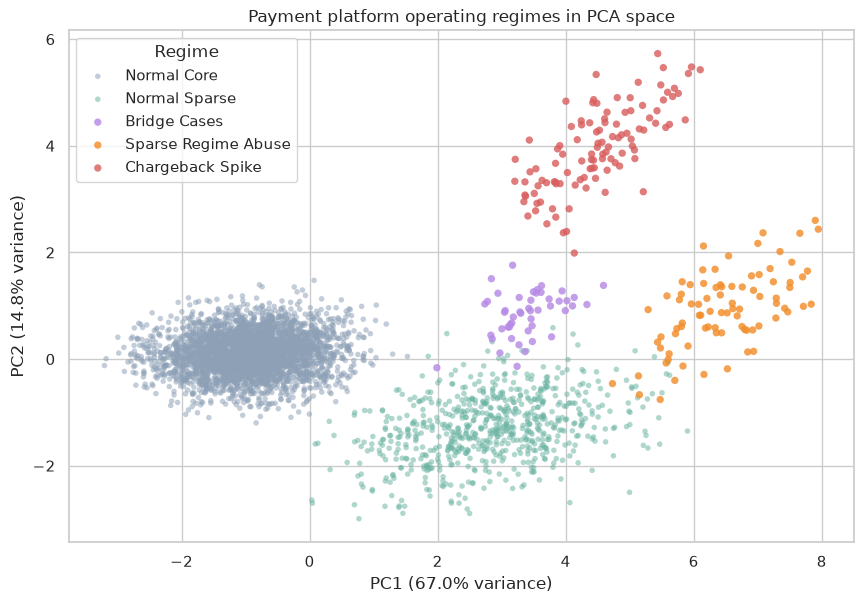

In [3]:
# Section focus: 5. Scaling and a Two-Dimensional View.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scaler = StandardScaler()
Z = scaler.fit_transform(payment_df[feature_cols])

pca = PCA(n_components=2, random_state=RANDOM_SEED)
pc = pca.fit_transform(Z)
payment_df['pc1'] = pc[:, 0]
payment_df['pc2'] = pc[:, 1]

fig, ax = plt.subplots(figsize=(8.8, 6.2))
plot_order = ['normal_core', 'normal_sparse', 'bridge_cases', 'sparse_regime_abuse', 'chargeback_spike']
colors = {
    'normal_core': PALETTE['normal_core'],
    'normal_sparse': PALETTE['normal_sparse'],
    'bridge_cases': '#b68ae6',
    'sparse_regime_abuse': '#f28e2b',
    'chargeback_spike': PALETTE['known_anomaly'],
}
for regime in plot_order:
    mask = payment_df['regime'].eq(regime)
    ax.scatter(
        payment_df.loc[mask, 'pc1'],
        payment_df.loc[mask, 'pc2'],
        s=16 if regime.startswith('normal') else 28,
        alpha=0.52 if regime.startswith('normal') else 0.82,
        color=colors[regime],
        label=regime.replace('_', ' ').title(),
        edgecolor='none',
    )
ax.set_title('Payment platform operating regimes in PCA space')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(title='Regime', loc='best', frameon=True)
plt.tight_layout()
plt.show()

The PCA view shows a dense operating core and a smaller sparse normal cloud. Some anomalies are visually separated, while others lie between or near normal regimes. That is the hard case for density methods: a point can be rare globally but still close to a legitimate sparse regime.

## 6. KDE Scores and Density Level Sets

For anomaly scoring, we use

$$
S_i^{\mathrm{KDE}} = -\log \hat{f}_h(z_i),
$$

where $z_i$ is the standardized feature vector. Larger scores mean lower estimated density.

Bandwidth selection can be handled by cross-validation for density likelihood, but the best likelihood bandwidth is not always the best operational alert bandwidth. We will fit several bandwidths and compare their alert behavior under a fixed review budget.

In [4]:
# Section focus: 6. KDE Scores and Density Level Sets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

bandwidth_grid = np.array([0.20, 0.30, 0.45, 0.65, 0.90, 1.20, 1.60])
search = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    {'bandwidth': bandwidth_grid},
    cv=5,
    n_jobs=-1,
)
search.fit(Z)
cv_bandwidth = search.best_params_['bandwidth']

kde_results = []
score_columns = []
review_budget = 0.04
for bandwidth in bandwidth_grid:
    kde = KernelDensity(kernel='gaussian', bandwidth=float(bandwidth))
    kde.fit(Z)
    score = -kde.score_samples(Z)
    column = f'kde_score_h_{bandwidth:.2f}'
    payment_df[column] = score
    score_columns.append(column)
    cutoff = np.quantile(score, 1 - review_budget)
    alert = score >= cutoff
    kde_results.append({
        'bandwidth': bandwidth,
        'selected_by_cv': bandwidth == cv_bandwidth,
        'cutoff_top_4_percent': cutoff,
        'alerts': int(alert.sum()),
        'precision': payment_df.loc[alert, 'known_anomaly'].mean(),
        'recall': payment_df.loc[alert & payment_df['known_anomaly'].eq(1)].shape[0] / payment_df['known_anomaly'].sum(),
        'false_positive_rate': payment_df.loc[alert & payment_df['known_anomaly'].eq(0)].shape[0] / payment_df['known_anomaly'].eq(0).sum(),
        'average_precision': average_precision_score(payment_df['known_anomaly'], score),
        'roc_auc': roc_auc_score(payment_df['known_anomaly'], score),
        'sparse_normal_share_of_false_alerts': payment_df.loc[alert & payment_df['known_anomaly'].eq(0), 'regime'].eq('normal_sparse').mean() if payment_df.loc[alert & payment_df['known_anomaly'].eq(0)].shape[0] else 0,
        'workload_hours': payment_df.loc[alert, 'review_minutes'].sum() / 60,
    })

kde_table = pd.DataFrame(kde_results)
formatters = {
    'bandwidth': '{:.2f}',
    'cutoff_top_4_percent': '{:.2f}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_positive_rate': '{:.1%}',
    'average_precision': '{:.1%}',
    'roc_auc': '{:.3f}',
    'sparse_normal_share_of_false_alerts': '{:.1%}',
    'workload_hours': '{:.1f}',
}
smart_display(kde_table.style.format(formatters))

,bandwidth,selected_by_cv,cutoff_top_4_percent,alerts,precision,recall,false_positive_rate,average_precision,roc_auc,sparse_normal_share_of_false_alerts,workload_hours
0,0.20,False,4.23,174,64.9%,47.1%,1.5%,60.2%,0.969,91.8%,77.2
1,0.30,False,6.58,174,67.8%,49.2%,1.4%,66.1%,0.980,94.6%,78.8
2,0.45,True,8.42,174,74.7%,54.2%,1.1%,75.5%,0.988,97.7%,81.9
3,0.65,False,9.47,174,83.9%,60.8%,0.7%,86.2%,0.993,96.4%,87.2
4,0.90,False,10.38,174,93.7%,67.9%,0.3%,93.5%,0.996,100.0%,92.8
5,1.20,False,11.26,174,98.9%,71.7%,0.0%,95.6%,0.997,100.0%,94.9
6,1.60,False,12.06,174,98.9%,71.7%,0.0%,94.2%,0.994,100.0%,94.7


The table separates two questions that are often mixed together:

1. Which bandwidth gives a good density fit under cross-validation?
2. Which bandwidth gives a useful alert queue under a fixed review budget?

The cross-validated bandwidth is a principled starting point, but the final launch decision should still inspect precision, recall, false positives, and which normal regimes are being alerted. Because this is a synthetic teaching case, we can use known labels to compare alert quality. In a real deployment, this same comparison would come from historical investigations, expert review, delayed labels, or staged monitoring feedback.

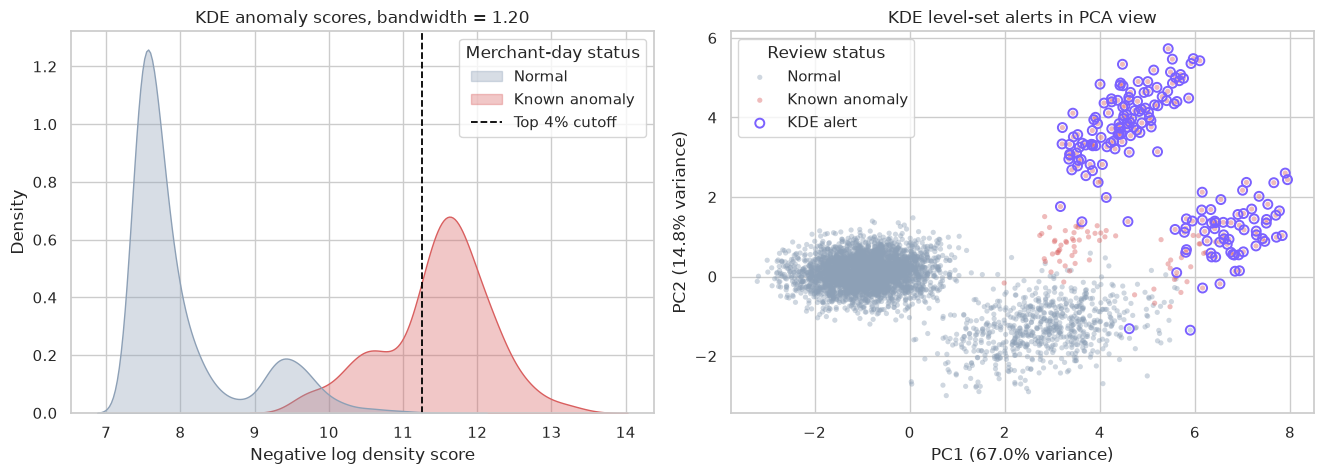

In [5]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommended_bandwidth = float(kde_table.sort_values(['average_precision', 'precision'], ascending=False).iloc[0]['bandwidth'])
recommended_column = f'kde_score_h_{recommended_bandwidth:.2f}'
payment_df['kde_score'] = payment_df[recommended_column]
kde_cutoff = np.quantile(payment_df['kde_score'], 1 - review_budget)
payment_df['kde_alert'] = payment_df['kde_score'] >= kde_cutoff

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9))

sns.kdeplot(
    data=payment_df,
    x='kde_score',
    hue='known_anomaly',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette={0: PALETTE['normal_core'], 1: PALETTE['known_anomaly']},
    ax=axes[0],
)
axes[0].axvline(kde_cutoff, color='black', linestyle='--', linewidth=1.3, label='Top 4% cutoff')
axes[0].set_title(f'KDE anomaly scores, bandwidth = {recommended_bandwidth:.2f}')
axes[0].set_xlabel('Negative log density score')
axes[0].set_ylabel('Density')
axes[0].legend(
    handles=[
        Patch(facecolor=PALETTE['normal_core'], edgecolor=PALETTE['normal_core'], alpha=0.35, label='Normal'),
        Patch(facecolor=PALETTE['known_anomaly'], edgecolor=PALETTE['known_anomaly'], alpha=0.35, label='Known anomaly'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.3, label='Top 4% cutoff'),
    ],
    title='Merchant-day status',
    frameon=True,
)

for known, label, color in [(0, 'Normal', PALETTE['normal_core']), (1, 'Known anomaly', PALETTE['known_anomaly'])]:
    subset = payment_df[payment_df['known_anomaly'].eq(known)]
    axes[1].scatter(subset['pc1'], subset['pc2'], s=14, alpha=0.42, color=color, label=label, edgecolor='none')
alert_subset = payment_df[payment_df['kde_alert']]
axes[1].scatter(
    alert_subset['pc1'],
    alert_subset['pc2'],
    s=42,
    facecolors='none',
    edgecolors=PALETTE['kde_alert'],
    linewidths=1.4,
    label='KDE alert',
)
axes[1].set_title('KDE level-set alerts in PCA view')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend(title='Review status', loc='best', frameon=True)

plt.tight_layout()
plt.show()

The KDE score distribution gives a useful visual threshold check. If normal and anomaly scores overlap heavily, a density threshold will need human review and careful escalation policy. If the top-score region captures mostly anomalies without over-concentrating on legitimate sparse merchants, KDE is a plausible review score.

The PCA panel should not be overinterpreted as the density model itself. KDE was fit in the full standardized feature space. The projection is only a visual audit of where the selected review cases sit.

## 7. DBSCAN Noise as an Alert Rule

DBSCAN has two parameters:

$$
\varepsilon = \text{neighborhood radius}, \qquad m = \text{minimum samples for a core point}.
$$

For each point $i$, define the $\varepsilon$-neighborhood as

$$
N_\varepsilon(i) = \{j: d(z_i,z_j) \le \varepsilon\}.
$$

A point is core if $|N_\varepsilon(i)| \ge m$. Points not connected to any dense component are labeled noise. In scikit-learn, DBSCAN labels those points as `-1`.

The challenge is that DBSCAN produces a binary noise flag, not a smooth ranking. To compare it with KDE under a fixed review budget, we will inspect multiple radius choices and report the resulting alert rate and quality.

In [6]:
# Section focus: 7. DBSCAN Noise as an Alert Rule.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def evaluate_binary_alert(alert, name):
    """Evaluate binary alert for the 06. Density-Based Anomaly Detection decision workflow.
    
    Parameters
    ----------
    alert : object
        The alert setting that controls the binary alert calculation in this notebook.
    name : object
        Readable name used to label a model, variable, scenario, or diagnostic object.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    alert = np.asarray(alert, dtype=bool)
    positives = payment_df['known_anomaly'].to_numpy().astype(bool)
    return {
        'detector': name,
        'alerts': int(alert.sum()),
        'alert_rate': alert.mean(),
        'precision': positives[alert].mean() if alert.sum() else np.nan,
        'recall': (alert & positives).sum() / positives.sum(),
        'false_positive_rate': (alert & ~positives).sum() / (~positives).sum(),
        'sparse_normal_share_of_false_alerts': payment_df.loc[alert & ~positives, 'regime'].eq('normal_sparse').mean() if (alert & ~positives).sum() else 0,
        'workload_hours': payment_df.loc[alert, 'review_minutes'].sum() / 60,
    }

min_samples = 25
eps_grid = np.round(np.linspace(0.70, 1.55, 10), 2)
dbscan_rows = []
labels_by_eps = {}
for eps in eps_grid:
    db = DBSCAN(eps=float(eps), min_samples=min_samples, n_jobs=-1)
    labels = db.fit_predict(Z)
    labels_by_eps[eps] = labels
    noise_alert = labels == -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    row = evaluate_binary_alert(noise_alert, f'DBSCAN eps={eps:.2f}')
    row['eps'] = eps
    row['min_samples'] = min_samples
    row['clusters'] = n_clusters
    dbscan_rows.append(row)

dbscan_table = pd.DataFrame(dbscan_rows)
smart_display(
    dbscan_table[[
        'eps', 'min_samples', 'clusters', 'alerts', 'alert_rate', 'precision', 'recall',
        'false_positive_rate', 'sparse_normal_share_of_false_alerts', 'workload_hours'
    ]].style.format({
        'eps': '{:.2f}',
        'alert_rate': '{:.1%}',
        'precision': '{:.1%}',
        'recall': '{:.1%}',
        'false_positive_rate': '{:.1%}',
        'sparse_normal_share_of_false_alerts': '{:.1%}',
        'workload_hours': '{:.1f}',
    })
)

,eps,min_samples,clusters,alerts,alert_rate,precision,recall,false_positive_rate,sparse_normal_share_of_false_alerts,workload_hours
0,0.70,25,3,869,20.0%,27.6%,100.0%,15.3%,94.0%,277.6
1,0.79,25,2,579,13.3%,41.5%,100.0%,8.3%,96.8%,210.8
2,0.89,25,2,402,9.3%,59.2%,99.2%,4.0%,98.8%,168.1
3,0.98,25,2,307,7.1%,76.9%,98.3%,1.7%,98.6%,146.9
4,1.08,25,1,254,5.9%,82.3%,87.1%,1.1%,100.0%,125.0
5,1.17,25,1,218,5.0%,89.4%,81.2%,0.6%,100.0%,112.9
6,1.27,25,2,170,3.9%,97.1%,68.8%,0.1%,100.0%,91.4
7,1.36,25,2,121,2.8%,97.5%,49.2%,0.1%,100.0%,65.1
8,1.46,25,2,56,1.3%,98.2%,22.9%,0.0%,100.0%,31.2
9,1.55,25,2,29,0.7%,96.6%,11.7%,0.0%,100.0%,15.1


DBSCAN changes the operational queue size as $\varepsilon$ changes. Smaller radii create more noise points and larger queues. Larger radii absorb more points into clusters and may miss subtle anomalies.

This is the governance tension: DBSCAN is excellent for discovering dense structure, but its binary noise label may fit the data geometry while failing to match a fixed staffing budget. In many production settings, a ranked score such as KDE is easier to operate because the queue size can be controlled directly.

,detector,alerts,alert_rate,precision,recall,false_positive_rate,sparse_normal_share_of_false_alerts,workload_hours
0,"KDE top 4%, h=1.20",174,4.0%,98.9%,71.7%,0.0%,100.0%,94.9
1,"DBSCAN noise, eps=1.27",170,3.9%,97.1%,68.8%,0.1%,100.0%,91.4


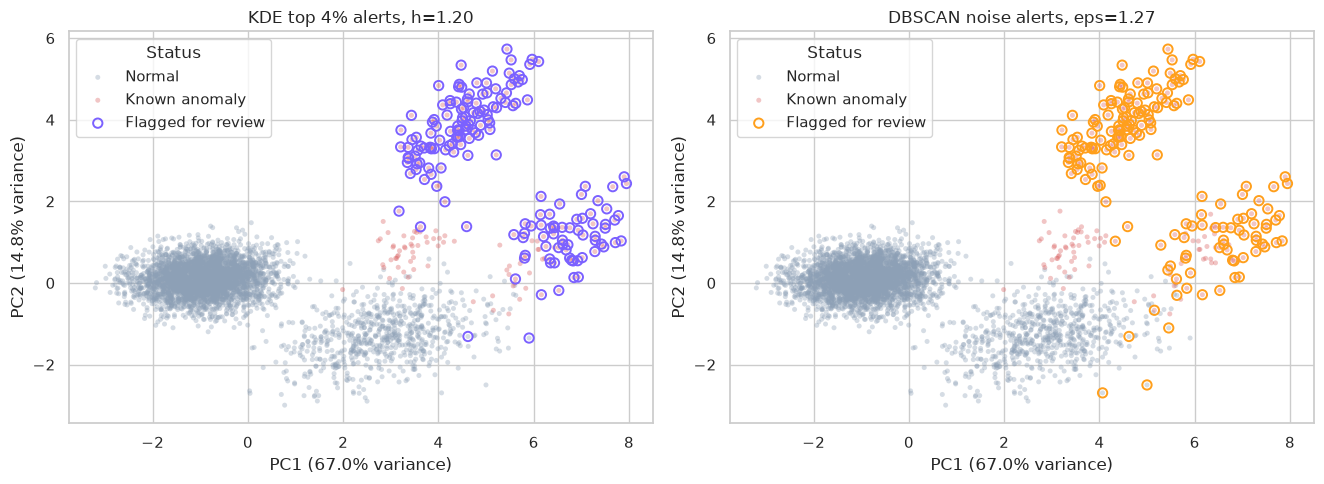

In [7]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

# Choose the DBSCAN setting whose alert rate is closest to the 4% review budget.
dbscan_choice = dbscan_table.assign(budget_gap=lambda d: (d['alert_rate'] - review_budget).abs()).sort_values('budget_gap').iloc[0]
chosen_eps = float(dbscan_choice['eps'])
payment_df['dbscan_label'] = labels_by_eps[chosen_eps]
payment_df['dbscan_noise'] = payment_df['dbscan_label'].eq(-1)

comparison_rows = []
comparison_rows.append(evaluate_binary_alert(payment_df['kde_alert'], f'KDE top 4%, h={recommended_bandwidth:.2f}'))
comparison_rows.append(evaluate_binary_alert(payment_df['dbscan_noise'], f'DBSCAN noise, eps={chosen_eps:.2f}'))
comparison = pd.DataFrame(comparison_rows)

smart_display(comparison.style.format({
    'alert_rate': '{:.1%}',
    'precision': '{:.1%}',
    'recall': '{:.1%}',
    'false_positive_rate': '{:.1%}',
    'sparse_normal_share_of_false_alerts': '{:.1%}',
    'workload_hours': '{:.1f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0))
for ax, flag_col, title, edge_color in [
    (axes[0], 'kde_alert', f'KDE top 4% alerts, h={recommended_bandwidth:.2f}', PALETTE['kde_alert']),
    (axes[1], 'dbscan_noise', f'DBSCAN noise alerts, eps={chosen_eps:.2f}', PALETTE['dbscan_noise']),
]:
    for known, label, color in [(0, 'Normal', PALETTE['normal_core']), (1, 'Known anomaly', PALETTE['known_anomaly'])]:
        subset = payment_df[payment_df['known_anomaly'].eq(known)]
        ax.scatter(subset['pc1'], subset['pc2'], s=13, alpha=0.36, color=color, label=label, edgecolor='none')
    flagged = payment_df[payment_df[flag_col]]
    ax.scatter(
        flagged['pc1'], flagged['pc2'], s=45, facecolors='none', edgecolors=edge_color,
        linewidths=1.4, label='Flagged for review'
    )
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.legend(title='Status', loc='best', frameon=True)
plt.tight_layout()
plt.show()

The comparison is deliberately operational. KDE is forced to produce a 4% queue. DBSCAN is not naturally budgeted, so we choose the radius that comes closest to that budget and then inspect the consequences.

When DBSCAN noise performs well, it is usually because true anomalies sit outside dense components. When it performs poorly, the usual reasons are parameter mismatch, varying density, sparse legitimate regimes, or anomalies that lie inside a dense region.

## 8. Bandwidth and Radius Sensitivity

Density methods are unusually sensitive to tuning parameters. A robust lecture notebook should not hide this. We should show how the decision changes as bandwidth or radius changes.

For KDE, bandwidth changes smoothness. For DBSCAN, radius changes what counts as a dense neighborhood. The practical question is whether the recommendation survives reasonable perturbations.

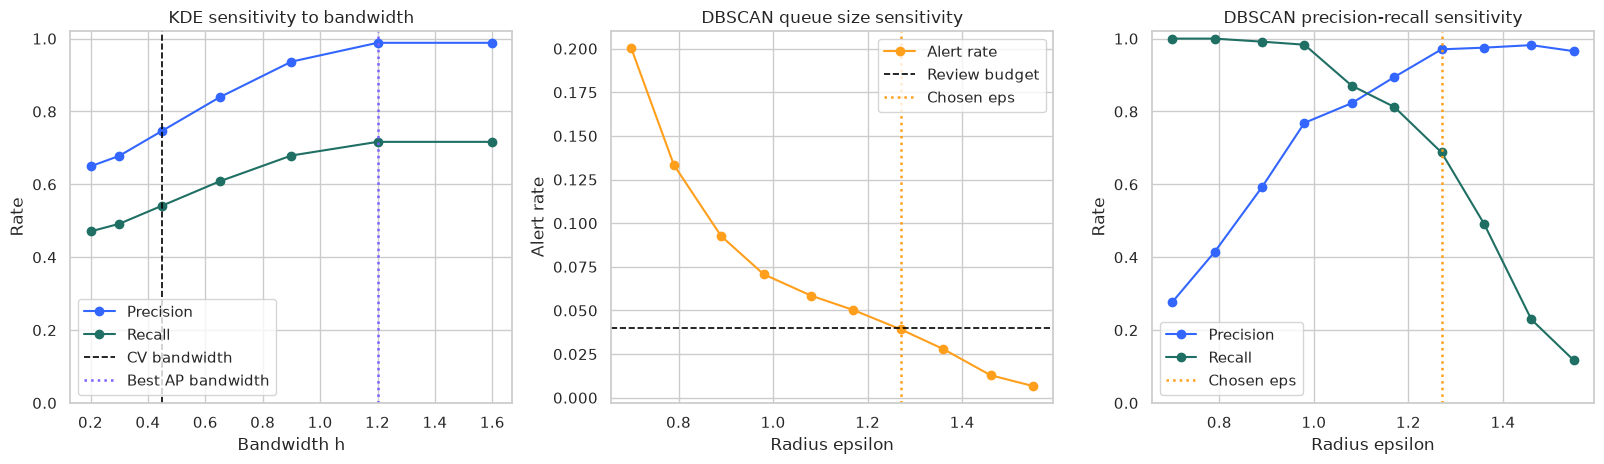

In [8]:
# Section focus: 8. Bandwidth and Radius Sensitivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.8))

axes[0].plot(kde_table['bandwidth'], kde_table['precision'], marker='o', label='Precision', color='#3366ff')
axes[0].plot(kde_table['bandwidth'], kde_table['recall'], marker='o', label='Recall', color='#1f6f64')
axes[0].axvline(cv_bandwidth, color='black', linestyle='--', linewidth=1.2, label='CV bandwidth')
axes[0].axvline(recommended_bandwidth, color=PALETTE['kde_alert'], linestyle=':', linewidth=1.8, label='Best AP bandwidth')
axes[0].set_title('KDE sensitivity to bandwidth')
axes[0].set_xlabel('Bandwidth h')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0, 1.02)
axes[0].legend(frameon=True)

axes[1].plot(dbscan_table['eps'], dbscan_table['alert_rate'], marker='o', color=PALETTE['dbscan_noise'], label='Alert rate')
axes[1].axhline(review_budget, color='black', linestyle='--', linewidth=1.2, label='Review budget')
axes[1].axvline(chosen_eps, color=PALETTE['dbscan_noise'], linestyle=':', linewidth=1.8, label='Chosen eps')
axes[1].set_title('DBSCAN queue size sensitivity')
axes[1].set_xlabel('Radius epsilon')
axes[1].set_ylabel('Alert rate')
axes[1].legend(frameon=True)

axes[2].plot(dbscan_table['eps'], dbscan_table['precision'], marker='o', label='Precision', color='#3366ff')
axes[2].plot(dbscan_table['eps'], dbscan_table['recall'], marker='o', label='Recall', color='#1f6f64')
axes[2].axvline(chosen_eps, color=PALETTE['dbscan_noise'], linestyle=':', linewidth=1.8, label='Chosen eps')
axes[2].set_title('DBSCAN precision-recall sensitivity')
axes[2].set_xlabel('Radius epsilon')
axes[2].set_ylabel('Rate')
axes[2].set_ylim(0, 1.02)
axes[2].legend(frameon=True)

plt.tight_layout()
plt.show()

Sensitivity plots are not optional decoration. They answer a governance question: *is the detector stable enough to launch?*

A method that looks good at one narrow parameter value may be too brittle for production. A method that remains useful across a range of plausible settings is easier to defend, monitor, and explain.

## 9. Precision-Recall Curves and Score Separation

KDE gives a continuous score, so we can inspect precision-recall behavior across many possible thresholds. DBSCAN gives a binary label in this notebook, so it appears as one operating point.

This distinction matters. Ranked scores allow teams to change queue size as staffing, risk appetite, and incident rates change. Binary labels require parameter changes to move the operating point.

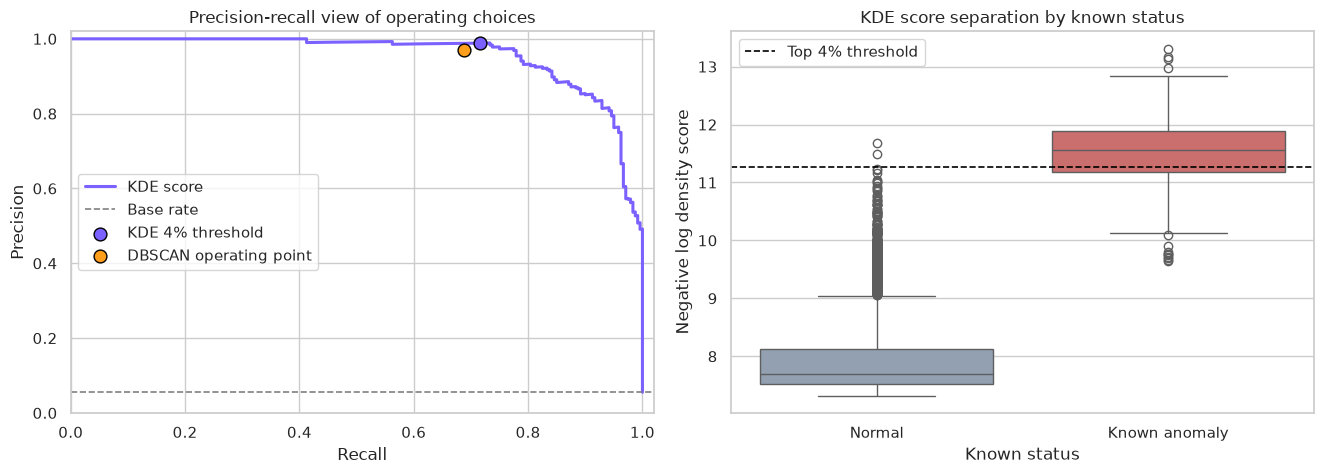

In [9]:
# Section focus: 9. Precision-Recall Curves and Score Separation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

precision, recall, _ = precision_recall_curve(payment_df['known_anomaly'], payment_df['kde_score'])
base_rate = payment_df['known_anomaly'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9))
axes[0].plot(recall, precision, color=PALETTE['kde_alert'], linewidth=2.2, label='KDE score')
axes[0].axhline(base_rate, color='gray', linestyle='--', linewidth=1.2, label='Base rate')
axes[0].scatter(
    comparison.loc[comparison['detector'].str.contains('KDE'), 'recall'],
    comparison.loc[comparison['detector'].str.contains('KDE'), 'precision'],
    s=85, color=PALETTE['kde_alert'], edgecolor='black', label='KDE 4% threshold', zorder=5,
)
axes[0].scatter(
    comparison.loc[comparison['detector'].str.contains('DBSCAN'), 'recall'],
    comparison.loc[comparison['detector'].str.contains('DBSCAN'), 'precision'],
    s=85, color=PALETTE['dbscan_noise'], edgecolor='black', label='DBSCAN operating point', zorder=5,
)
axes[0].set_title('Precision-recall view of operating choices')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1.02)
axes[0].set_ylim(0, 1.02)
axes[0].legend(frameon=True)

score_plot = payment_df.copy()
score_plot['Known status'] = np.where(score_plot['known_anomaly'].eq(1), 'Known anomaly', 'Normal')
sns.boxplot(
    data=score_plot,
    x='Known status', y='kde_score', hue='Known status',
    palette={'Normal': PALETTE['normal_core'], 'Known anomaly': PALETTE['known_anomaly']},
    legend=False, ax=axes[1]
)
axes[1].axhline(kde_cutoff, color='black', linestyle='--', linewidth=1.2, label='Top 4% threshold')
axes[1].set_title('KDE score separation by known status')
axes[1].set_xlabel('Known status')
axes[1].set_ylabel('Negative log density score')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

Precision-recall curves are especially useful when anomalies are rare. Accuracy can look excellent even for a useless detector because most cases are normal. Precision tells us how much human review effort is likely to be productive; recall tells us how much known failure mass the queue captures.

The boxplot adds a calibration check. A detector can have a good top-of-queue performance while still showing overlap between normal and anomalous scores. That overlap is why review workflows, explanations, and feedback loops matter.

## 10. Explaining a Density Alert

A low-density alert should be explained in terms a reviewer can act on. For a selected KDE alert, we compare the case to its nearest normal neighbors in standardized space.

The explanation is not causal. It answers a narrower question: *which features make this case locally unusual relative to similar historical cases?*

,feature,case_value,neighbor_mean,neighbor_standardized_gap
2,Chargeback Rate (%),3.98,1.89,7.92
3,Refund Rate (%),14.46,8.26,6.59
4,Manual Review Rate (%),9.48,6.16,3.08
0,Transactions,158.18,98.57,1.74
1,Avg Ticket,182.43,216.37,-0.82
5,Account Age Months,7.86,11.42,-0.51


,Quantity,Value
0,Selected case id,4238
1,Known label,1
2,Regime,sparse_regime_abuse
3,KDE score,13.31
4,KDE cutoff,11.26
5,DBSCAN noise?,True
6,Nearest-neighbor sparse-normal share,100.0%


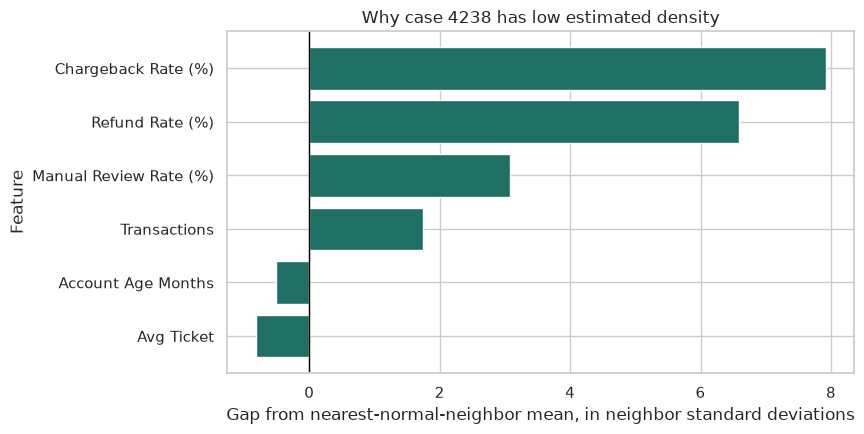

In [10]:
# Section focus: 10. Explaining a Density Alert.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

# Pick the highest-scoring true KDE alert if possible; otherwise pick the highest-scoring KDE alert.
alert_pool = payment_df[payment_df['kde_alert']].copy()
true_alert_pool = alert_pool[alert_pool['known_anomaly'].eq(1)]
selected_idx = (true_alert_pool if len(true_alert_pool) else alert_pool).sort_values('kde_score', ascending=False).index[0]
selected = payment_df.loc[selected_idx]

normal_mask = payment_df['known_anomaly'].eq(0)
nn = NearestNeighbors(n_neighbors=30)
nn.fit(Z[normal_mask])
normal_indices = payment_df.index[normal_mask].to_numpy()
distances, neighbor_positions = nn.kneighbors(Z[[selected_idx]])
neighbor_idx = normal_indices[neighbor_positions[0]]
neighbors = payment_df.loc[neighbor_idx]

selected_scaled = pd.Series(Z[selected_idx], index=feature_cols)
neighbor_scaled_mean = pd.Series(Z[neighbor_idx].mean(axis=0), index=feature_cols)
neighbor_scaled_sd = pd.Series(Z[neighbor_idx].std(axis=0), index=feature_cols).replace(0, np.nan)
standardized_gap = (selected_scaled - neighbor_scaled_mean) / neighbor_scaled_sd

explanation = pd.DataFrame({
    'feature': [name.replace('_', ' ').title().replace('Pct', '(%)') for name in feature_cols],
    'case_value': selected[feature_cols].to_numpy(dtype=float),
    'neighbor_mean': neighbors[feature_cols].mean().to_numpy(dtype=float),
    'neighbor_standardized_gap': standardized_gap.to_numpy(dtype=float),
}).sort_values('neighbor_standardized_gap', key=lambda s: s.abs(), ascending=False)

case_summary = pd.DataFrame({
    'Quantity': [
        'Selected case id',
        'Known label',
        'Regime',
        'KDE score',
        'KDE cutoff',
        'DBSCAN noise?',
        'Nearest-neighbor sparse-normal share',
    ],
    'Value': [
        str(selected_idx),
        str(int(selected['known_anomaly'])),
        str(selected['regime']),
        f'{selected["kde_score"]:.2f}',
        f'{kde_cutoff:.2f}',
        str(bool(selected['dbscan_noise'])),
        f'{neighbors["regime"].eq("normal_sparse").mean():.1%}',
    ],
})

smart_display(explanation.style.format({
    'case_value': '{:.2f}',
    'neighbor_mean': '{:.2f}',
    'neighbor_standardized_gap': '{:.2f}',
}))
smart_display(case_summary)

fig, ax = plt.subplots(figsize=(8.8, 4.5))
plot_data = explanation.sort_values('neighbor_standardized_gap')
ax.barh(plot_data['feature'], plot_data['neighbor_standardized_gap'], color=PALETTE['decision'])
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'Why case {selected_idx} has low estimated density')
ax.set_xlabel('Gap from nearest-normal-neighbor mean, in neighbor standard deviations')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

The selected alert is unusual because of a small set of feature gaps relative to nearby normal cases. This is more useful than simply saying "the density is low." Reviewers need to know whether the alert is driven by chargebacks, refunds, manual review rates, merchant age, transaction volume, or some combination.

The nearest-neighbor context also helps detect failure modes. If a flagged case's nearest neighbors are mostly sparse legitimate merchants, the team should be careful before treating the alert as high-risk.

## 11. Decision Memo

The final step is to convert the density analysis into an operational recommendation. A good memo should avoid treating density as truth. It should say which detector is recommended, what threshold is used, what failure modes are known, and how review feedback will be used.

In [11]:
# Section focus: 11. Decision Memo.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

kde_metrics = comparison[comparison['detector'].str.contains('KDE')].iloc[0]
db_metrics = comparison[comparison['detector'].str.contains('DBSCAN')].iloc[0]

memo = pd.DataFrame({
    'Memo item': [
        'Recommended launch score',
        'Operating threshold',
        'Expected queue size',
        'Expected precision and recall',
        'Role of DBSCAN',
        'Main false-alert risk',
        'Monitoring plan',
        'Human-review instruction',
    ],
    'Decision note': [
        f'Use KDE negative log density with bandwidth h = {recommended_bandwidth:.2f} as the first-pass ranked score.',
        f'Flag the top {review_budget:.0%} of merchant-days by KDE score; current cutoff is {kde_cutoff:.2f}.',
        f'Expected alert rate is {kde_metrics["alert_rate"]:.1%}, or {int(kde_metrics["alerts"])} cases in this batch, requiring about {kde_metrics["workload_hours"]:.1f} review hours.',
        f'Estimated precision is {kde_metrics["precision"]:.1%}; estimated recall is {kde_metrics["recall"]:.1%} using synthetic known labels.',
        f'Use DBSCAN as a structural diagnostic. At eps = {chosen_eps:.2f}, it produces {int(db_metrics["alerts"])} noise cases with precision {db_metrics["precision"]:.1%}.',
        'Sparse legitimate merchant regimes can look low-density; track false alerts by merchant segment and avoid automatic punitive action.',
        'Monitor score drift, alert volume, sparse-normal share of false alerts, bandwidth sensitivity, and review-confirmed precision.',
        'Show nearest-neighbor feature gaps with each alert so analysts can distinguish plausible risk from legitimate rarity.',
    ],
})

smart_display(memo)

,Memo item,Decision note
0,Recommended launch score,Use KDE negative log density with bandwidth h = 1.20 as the first-pass ranked score.
1,Operating threshold,Flag the top 4% of merchant-days by KDE score; current cutoff is 11.26.
2,Expected queue size,"Expected alert rate is 4.0%, or 174 cases in this batch, requiring about 94.9 review hours."
3,Expected precision and recall,Estimated precision is 98.9%; estimated recall is 71.7% using synthetic known labels.
4,Role of DBSCAN,"Use DBSCAN as a structural diagnostic. At eps = 1.27, it produces 170 noise cases with precision 97.1%."
5,Main false-alert risk,Sparse legitimate merchant regimes can look low-density; track false alerts by merchant segment and avoid automatic punitive action.
6,Monitoring plan,"Monitor score drift, alert volume, sparse-normal share of false alerts, bandwidth sensitivity, and review-confirmed precision."
7,Human-review instruction,Show nearest-neighbor feature gaps with each alert so analysts can distinguish plausible risk from legitimate rarity.


For Decision Memo, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


## Key Takeaways

- Density-based anomaly detection scores cases by how rarely they appear under an estimated normal distribution.
- KDE produces a continuous score, making it convenient for fixed review budgets.
- Bandwidth is a modeling decision. It controls whether the detector sees local structure or smooths it away.
- DBSCAN identifies dense components and labels unsupported points as noise, but its queue size depends sharply on $\varepsilon$ and `min_samples`.
- Sparse normal regimes are the central risk in density-based monitoring.
- A low-density alert is not a causal explanation or proof of fraud. It is a triage signal that needs context.
- Production density detectors should be monitored for threshold drift, segment-level false alerts, parameter sensitivity, and review feedback.

## References

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Hahsler, M., Piekenbrock, M., & Doran, D. (2019). dbscan: Fast density-based clustering with R. *Journal of Statistical Software, 91*(1), 1-30. [https://doi.org/10.18637/jss.v091.i01](https://doi.org/10.18637/jss.v091.i01)

Parzen, E. (1962). On estimation of a probability density function and mode. *The Annals of Mathematical Statistics, 33*(3), 1065-1076. [https://doi.org/10.1214/aoms/1177704472](https://doi.org/10.1214/aoms/1177704472)

Rosenblatt, M. (1956). Remarks on some nonparametric estimates of a density function. *The Annals of Mathematical Statistics, 27*(3), 832-837. [https://doi.org/10.1214/aoms/1177728190](https://doi.org/10.1214/aoms/1177728190)

Su, S., Xiao, L., Ruan, L., Gu, F., Li, S., & Wang, Z. (2019). An efficient density-based local outlier detection approach for scattered data. *IEEE Access, 7*, 1006-1020. [https://doi.org/10.1109/ACCESS.2018.2886197](https://doi.org/10.1109/ACCESS.2018.2886197)
